# Модели семейства ARIMA для предсказания стоимости акций

ARIMA модели - семейство моделей анализа временных рядов. Модель SARIMAX даже позволяет добавить внешние признаки, например, цены других акций, или стоимость индекса мосбиржи.

SARIMAX состоит из нескольких частей:
- **S** - сезонность
- **AR** - авторегрессия (зависимость текущего значения от предыдущих значений ряда)
- **I** - интегрирование (дифференцируем ряд, чтобы сделать его стационарным)
- **MA** - скользящее среднее (зависимость текущего значения от прошлых ошибок модели)
- **X** - eXogenous variables (внешние факторы)

# Функции

In [158]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def train_test_split_by_date(df, date_column='begin', target_column='close', test_size=0.2):
    """
    Разбивает данные на train/test по дате и возвращает X, y
    
    Args:
        df: DataFrame с колонкой 'begin'
        target_column: название целевой переменной
        test_size: доля тестовых данных (0.2 = 20%)
    """
    df = df.sort_values(date_column).reset_index(drop=True)
    
    # Вычисляем индекс разбиения
    split_idx = int(len(df) * (1 - test_size))
    
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
    
    print(f"Train: {train_df[date_column].min()} - {train_df[date_column].max()} ({len(train_df)} samples)")
    print(f"Test:  {test_df[date_column].min()} - {test_df[date_column].max()} ({len(test_df)} samples)")
    
    # Удаляем колонку 'begin' и разделяем на X, y
    X_train = train_df.drop(columns=[date_column, target_column])
    y_train = train_df[target_column]
    
    X_test = test_df.drop(columns=[date_column, target_column])
    y_test = test_df[target_column]
    
    print(f"Признаков: {X_train.shape[1]}")
    
    return X_train, X_test, y_train, y_test

def visualize_predictions_comparison(
    results_df, title, y_label, date_column='begin', target_column='close', predict_column='predict',):
    """
    Визуализирует сравнение предсказаний и реальных изменений цены
    
    Args:
        results_df: DataFrame
        title: str, заголовок графика
        y_label: str, название оси Y
        date_column: str, название столбца с датой
        target_column: str, название столбца с target значениями
        predict_column: str, название столбца с предсказанными значениями
    """
    # Конвертируем дату если нужно
    if results_df[date_column].dtype == 'object':
        results_df = results_df.copy()
        results_df[date_column] = pd.to_datetime(results_df[date_column])
    
    # Сортируем по дате
    results_df = results_df.sort_values(date_column)
    
    fig = go.Figure()

    # Target
    fig.add_trace(
        go.Scatter(
            x=results_df[date_column],
            y=results_df[target_column],
            mode="lines+markers",
            name="target",
            line=dict(width=3, color="#2E8B57"),
            marker=dict(symbol="circle", size=6),
            opacity=0.8
        )
    )

    # Prediction
    fig.add_trace(
        go.Scatter(
            x=results_df[date_column],
            y=results_df[predict_column],
            mode="lines+markers",
            name="prediction",
            line=dict(width=3, color="#DC143C"),
            marker=dict(symbol="square", size=6),
            opacity=0.8
        )
    )

    # Нулевая линия
    fig.add_hline(
        y=0,
        line_width=1,
        line_dash="solid",
        line_color="black",
        opacity=0.5
    )

    fig.update_layout(
        title=dict(
            text=title,
            x=0.5,
            xanchor="center",
            font=dict(size=18)
        ),
        xaxis_title="Дата",
        yaxis_title=y_label,
        template="plotly_white",
        width=1200,
        height=600,
        hovermode="x unified"
    )

    fig.update_xaxes(
        tickangle=45,
        showgrid=True
    )

    fig.update_yaxes(
        showgrid=True
    )

    fig.show()

def evaluate_regression(y_test, y_pred, model_name=""):
    """Оценивает результаты регрессии"""
    print(f"\n{'='*50}")
    print(f"📊 МОДЕЛЬ: {model_name}")
    print(f"{'='*50}")
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Accuracy направления (важно для торговли)
    direction_accuracy = np.mean((y_test > 0) == (y_pred > 0))
    
    print(f"MAE: {mae:.4f}%")
    print(f"RMSE: {rmse:.4f}%")
    print(f"R²: {r2:.4f}")
    print(f"Accuracy направления: {direction_accuracy:.4f}")

def add_target_after_time_delta(df, time_delta, date_column='begin', price_column='close', target_date_column='target_date', target_price_column='target'):
    """Добавляет столбец с целевой переменной - изменением цены через time_delta дней"""
    df = df.copy()
    df[target_price_column] = df[price_column].shift(-time_delta)
    df[target_date_column] = df[date_column].shift(-time_delta)
    return df

In [ ]:
def log_return(series, periods=1):
    return np.log(series / series.shift(periods))


def inverse_log_return(log_ret, prev_price):
    return prev_price * np.exp(log_ret)

In [195]:
def _test_log_return():
    prices = pd.Series([100.0, 110.0, 121.0])
    log_ret = log_return(prices)
    log_ret_reversed = inverse_log_return(log_ret, prices.shift(1))
    assert np.allclose(prices[1:], log_ret_reversed[1:], rtol=1e-6)

_test_log_return()

## 1. Анализ стоимости акций

### 1.1. Загружаем данные

In [101]:
# Хак, чтобы добавить корень проекта в path для импорта модулей
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[1]))
sys.path

['/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '',
 '/home/codevryn/stocks-advisor/.venv/lib/python3.12/site-packages',
 '/home/codevryn/stocks-advisor',
 '/home/codevryn/stocks-advisor']

In [102]:
from datetime import datetime

from app.core.clients.moex import Boards, Engines, Interval, Markets, MOEXClient

moex_client = MOEXClient()
stocks_data = await moex_client.get_data(
    tickers=['GAZP', 'LKOH', 'ROSN', 'SBER'],
    engine=Engines.STOCK,
    market=Markets.SHARES,
    board=Boards.TQBR,
    start_date=datetime(2022, 5, 1),
    end_date=datetime.now(),
    interval=Interval.HOUR_1,
)

In [103]:
stocks_data.keys()

dict_keys(['GAZP', 'LKOH', 'ROSN', 'SBER'])

In [104]:
stocks_data['GAZP'].describe()

,open,close,high,low,value,volume,begin,end
count,15854.000000,15854.000000,15854.000000,15854.000000,1.585400e+04,1.585400e+04,15854,15854
mean,152.024283,152.005267,152.445793,151.553846,4.854803e+08,3.222980e+06,2024-06-15 17:39:33.129809408,2024-06-15 18:39:21.870695168
min,105.620000,105.650000,105.850000,105.220000,3.017040e+04,2.600000e+02,2022-05-04 09:00:00,2022-05-04 09:59:59
25%,127.040000,127.040000,127.390000,126.700000,1.031847e+08,6.989925e+05,2023-07-04 12:15:00,2023-07-04 13:14:59
50%,153.150000,153.120000,153.615000,152.610000,2.484646e+08,1.650730e+06,2024-07-16 16:30:00,2024-07-16 17:29:59
75%,167.600000,167.607500,167.990000,167.220000,5.574946e+08,3.784892e+06,2025-06-11 18:45:00,2025-06-11 19:42:32.750000128
max,320.800000,320.800000,322.990000,319.590000,2.385369e+10,1.410863e+08,2026-03-12 13:00:00,2026-03-12 13:48:06
std,32.386308,32.367157,32.535706,32.203518,8.563318e+08,5.249270e+06,NaN,NaN


In [105]:
stocks_data['GAZP'].head()

,open,close,high,low,value,volume,begin,end,ticker
0,241.00,241.00,241.00,241.00,1.779544e+07,73840,2022-05-04 09:00:00,2022-05-04 09:59:59,GAZP
1,241.01,238.90,244.39,238.00,1.687852e+09,7012280,2022-05-04 10:00:00,2022-05-04 10:59:59,GAZP
2,238.95,233.80,240.20,233.50,1.187417e+09,5025080,2022-05-04 11:00:00,2022-05-04 11:59:59,GAZP
3,233.71,235.63,236.30,233.17,5.070772e+08,2159900,2022-05-04 12:00:00,2022-05-04 12:59:59,GAZP
4,235.63,234.61,235.84,233.90,3.604205e+08,1535620,2022-05-04 13:00:00,2022-05-04 13:59:59,GAZP


### 1.2. Обработка данных

In [106]:
stocks_data_processed = {}

for k, v_df in stocks_data.items():
    stocks_data_processed[k] = v_df[['begin', 'close']]

stocks_data_processed['GAZP'].head()

,begin,close
0,2022-05-04 09:00:00,241.00
1,2022-05-04 10:00:00,238.90
2,2022-05-04 11:00:00,233.80
3,2022-05-04 12:00:00,235.63
4,2022-05-04 13:00:00,234.61


In [107]:
# Возьмем только основную сессию

stocks_data_main_session = {}

for ticker, df in stocks_data_processed.items():
    df = df.copy()
    df['hour'] = df['begin'].dt.hour
    # Основная сессия на Мосбирже: с 9:50 по 18:50.
    stocks_data_main_session[ticker] = df[df['hour'].between(10, 18)].drop(columns='hour')
    # Уберем выходные дни
    stocks_data_main_session[ticker] = stocks_data_main_session[ticker][stocks_data_main_session[ticker]['begin'].dt.dayofweek < 5]

stocks_data_main_session['GAZP'].shape

(8785, 2)

In [108]:
# Посмотрим на данные

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=stocks_data_processed['GAZP']["begin"],
        y=stocks_data_processed['GAZP']["close"],
        mode="lines",
        name="Close price"
    )
)

fig.update_layout(
    title="GAZP",
    xaxis_title="Date",
    yaxis_title="Price",
    template="plotly_white"
)

fig.show()

### 1.3. Анализ цены акций

Пока попробуем проанализировать цены акций "в лоб" для бэйзлайна

In [109]:
# # Добавим разные таргеты:
# # - цена через час
# # - цена через день
# # - цена через неделю

# stocks_data_1h = {}
# stocks_data_1d = {}
# stocks_data_1w = {}

# for ticker, df in stocks_data_processed.items():
#     stocks_data_1h[ticker] = add_target_after_time_delta(df, time_delta=1, date_column='begin', price_column='close', target_price_column='target')
#     stocks_data_1d[ticker] = add_target_after_time_delta(df, time_delta=24, date_column='begin', price_column='close', target_price_column='target')
#     stocks_data_1w[ticker] = add_target_after_time_delta(df, time_delta=24*7, date_column='begin', price_column='close', target_price_column='target')

# display(stocks_data_1h['GAZP'].head())
# stocks_data_1h['GAZP'].shape

In [201]:
# Для предсказания на следующую неделю.
# Сгруппируем по дням и добавим таргеты.

stocks_data_1w_daily = {}
for ticker, df in stocks_data_main_session.items():
    df_daily = df.resample('D', on='begin').last().dropna().reset_index()
    stocks_data_1w_daily[ticker] = add_target_after_time_delta(df_daily, time_delta=5, date_column='begin', price_column='close', target_price_column='target')
    stocks_data_1w_daily[ticker] = stocks_data_1w_daily[ticker].dropna().reset_index(drop=True)

display(stocks_data_1w_daily['GAZP'].head())
stocks_data_1w_daily['GAZP'].shape

,begin,close,target,target_date
0,2022-05-04,234.16,235.52,2022-05-13
1,2022-05-05,238.60,244.20,2022-05-16
2,2022-05-06,240.10,258.80,2022-05-17
3,2022-05-11,241.99,264.84,2022-05-18
4,2022-05-12,230.56,266.68,2022-05-19


(972, 4)

In [202]:
stocks_data_1w_daily['GAZP'][stocks_data_1w_daily['GAZP']['begin'].dt.year == 2025].count()

begin          253
close          253
target         253
target_date    253
dtype: int64

In [203]:
stocks_data_1w_daily['GAZP'].tail(20)

,begin,close,target,target_date
952,2026-02-06,125.35,126.77,2026-02-13
953,2026-02-09,124.21,126.75,2026-02-16
954,2026-02-10,122.99,125.67,2026-02-17
955,2026-02-11,125.25,126.30,2026-02-18
956,2026-02-12,125.86,125.88,2026-02-19
957,2026-02-13,126.77,126.08,2026-02-20
958,2026-02-16,126.75,127.87,2026-02-23
959,2026-02-17,125.67,126.27,2026-02-24
960,2026-02-18,126.30,126.97,2026-02-25
961,2026-02-19,125.88,126.57,2026-02-26


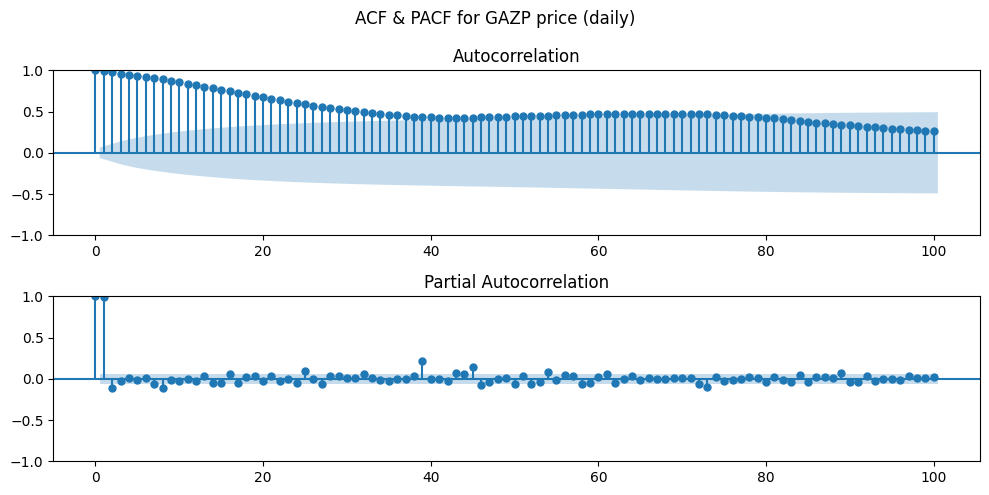

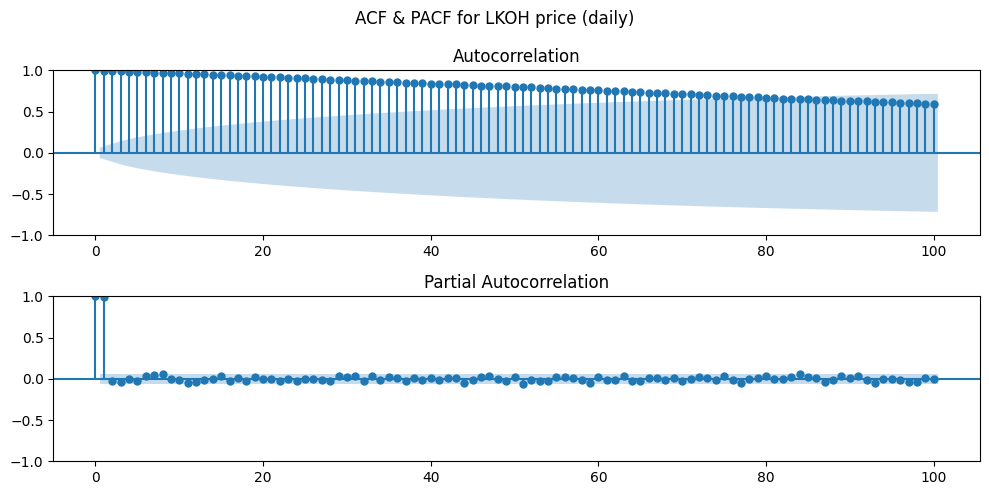

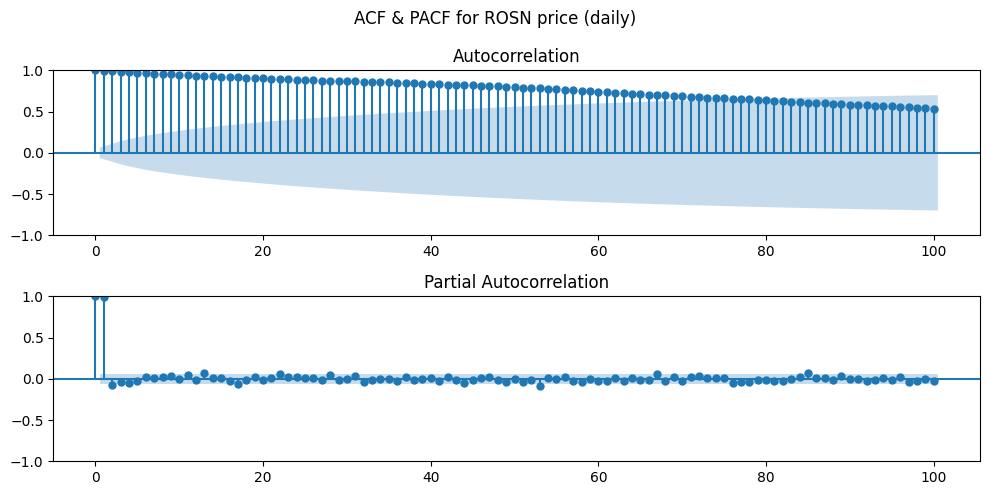

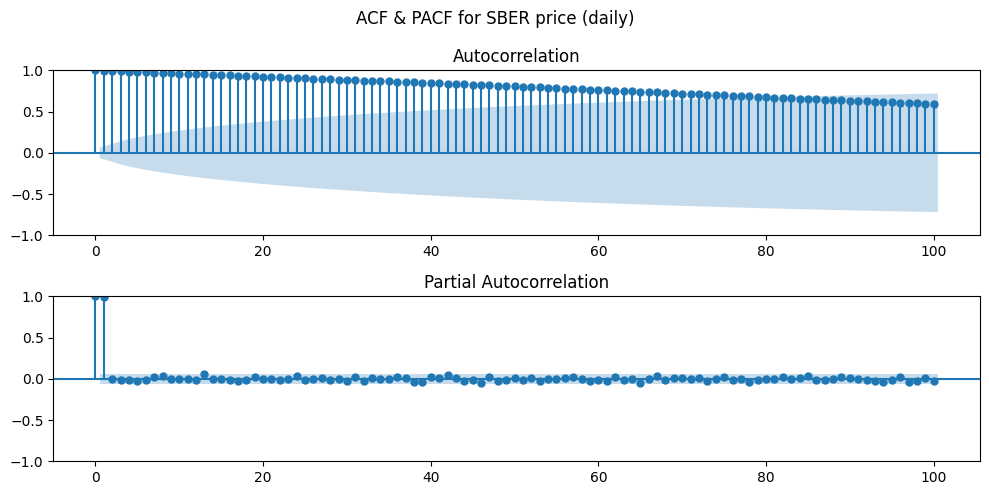

In [204]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


for ticker, df in stocks_data_1w_daily.items():
    fig, ax = plt.subplots(2, 1, figsize=(10, 5))
    fig.suptitle(f'ACF & PACF for {ticker} price (daily)')
    plot_acf(df['close'], lags=100, ax=ax[0])
    plot_pacf(df['close'], lags=100, ax=ax[1])
    plt.tight_layout()
    plt.show()

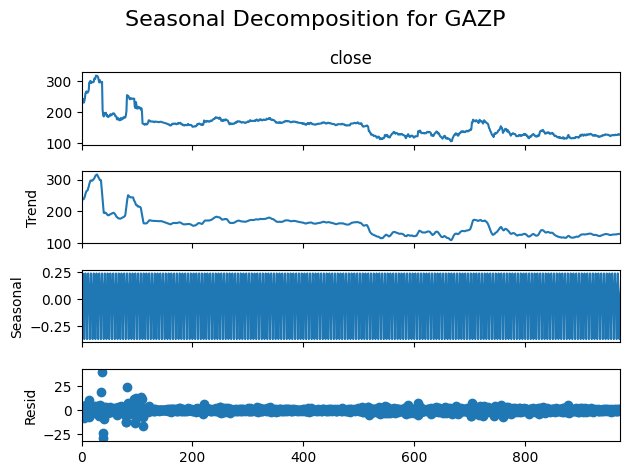

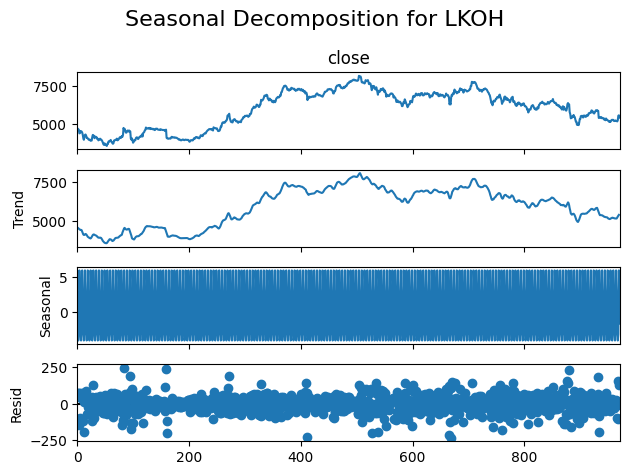

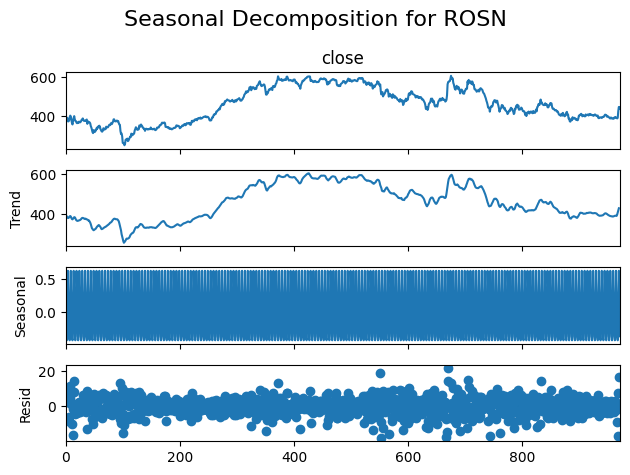

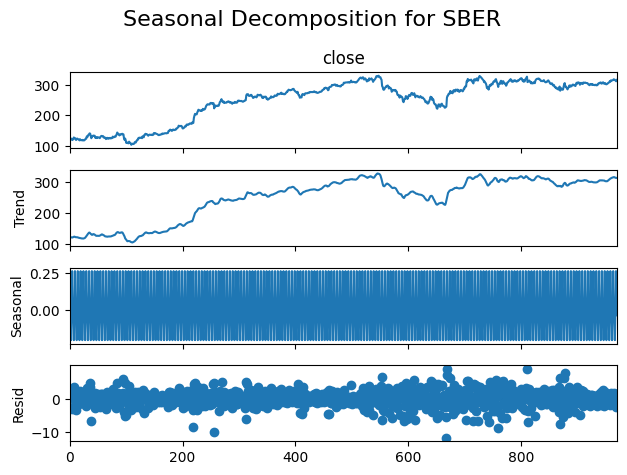

In [205]:
from statsmodels.tsa.seasonal import seasonal_decompose

for ticker, df in stocks_data_1w_daily.items():
    res = seasonal_decompose(df['close'], period=5, model='additive')
    fig = res.plot()
    fig.suptitle(f"Seasonal Decomposition for {ticker}", fontsize=16)
    plt.tight_layout()
    plt.show()

In [206]:
stocks_data_1w_daily_df = pd.concat(stocks_data_1w_daily.values(), keys=stocks_data_1w_daily.keys()).reset_index(level=0).rename(columns={'level_0': 'company'})

In [207]:
fig = go.Figure()

for ticker in stocks_data_1w_daily_df['company'].unique():
    df = stocks_data_1w_daily_df[stocks_data_1w_daily_df['company'] == ticker]
    fig.add_trace(
        go.Scatter(
            x=df['begin'],
            y=df['close'],
            mode="lines",
            name=ticker
        )
    )

fig.update_layout(
    title="Stock Prices (Daily)",
    xaxis_title="Date",
    yaxis_title="Price",
    template="plotly_white"
)
fig.show()

In [208]:
# Log scale

fig = go.Figure()

for ticker in stocks_data_1w_daily_df['company'].unique():
    df = stocks_data_1w_daily_df[stocks_data_1w_daily_df['company'] == ticker]
    fig.add_trace(
        go.Scatter(
            x=df['begin'],
            y=np.log(df['close']),
            mode="lines",
            name=ticker
        )
    )

fig.update_layout(
    title="Stock Prices (Daily, Log Scale)",
    xaxis_title="Date",
    yaxis_title="Log(Price)",
    template="plotly_white"
)
fig.show()

Итоги исследования цены акций:
- Сезонность присутствует, но почти незаметная
- График ACF медленно падает. Есть тренд.
- На графике PACF все значения, кроме 1, находятся около "синей зоны".

Получается, что есть зависимость между многими предыдущими значениями, но прямых зависимостей нет.

Модели сложно будет адекватно предсказать такое. Попробуем взять что-нибудь другое в качестве target.

### 1.4. Анализ доходности

Попробуем взять не цену акций, а доходность акции, если купим сегодня, а продадим через неделю.

Возьмем log доходность:
$$
r_{t,t+5} = \log(P_{t+5}) - \log(P_t)
$$

In [220]:
# Посчитаем log доходность для всех акций

stocks_returns_1w_daily = {}

for ticker, df in stocks_data_1w_daily.items():
    df = df.copy()
    df['log_return'] = np.log(df["target"]) - np.log(df["close"])
    df['log_return2'] = log_return(df['close'], periods=5)
    stocks_returns_1w_daily[ticker] = df.dropna().reset_index(drop=True)

display(stocks_returns_1w_daily['GAZP'].head())
stocks_returns_1w_daily['GAZP'].shape

,begin,close,target,target_date,log_return,log_return2
0,2022-05-13,235.52,263.00,2022-05-20,0.110358,0.005791
1,2022-05-16,244.20,263.00,2022-05-23,0.074166,0.023199
2,2022-05-17,258.80,265.80,2022-05-24,0.026689,0.075000
3,2022-05-18,264.84,271.40,2022-05-25,0.024468,0.090229
4,2022-05-19,266.68,295.89,2022-05-26,0.103938,0.145538


(967, 6)

In [221]:
# График log доходности, рядом с графиком цены

from plotly.subplots import make_subplots

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(x=stocks_returns_1w_daily['GAZP'].index, y=stocks_returns_1w_daily['GAZP']['close'], name="price"),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(x=stocks_returns_1w_daily['GAZP'].index, y=stocks_returns_1w_daily['GAZP']['log_return'], name="log return after 1 week"),
    secondary_y=True,
)

fig.add_trace(
    go.Scatter(x=stocks_returns_1w_daily['GAZP'].index, y=stocks_returns_1w_daily['GAZP']['log_return2'], name="log return 2 after 1 week"),
    secondary_y=True,
)


# Add figure title
fig.update_layout(
    title_text="GAZP: Price and Log Return After 1 Week"
)

fig.update_xaxes(title_text="Date")

fig.update_yaxes(title_text="price", secondary_y=False)
fig.update_yaxes(title_text="log return", secondary_y=True)

fig.show()

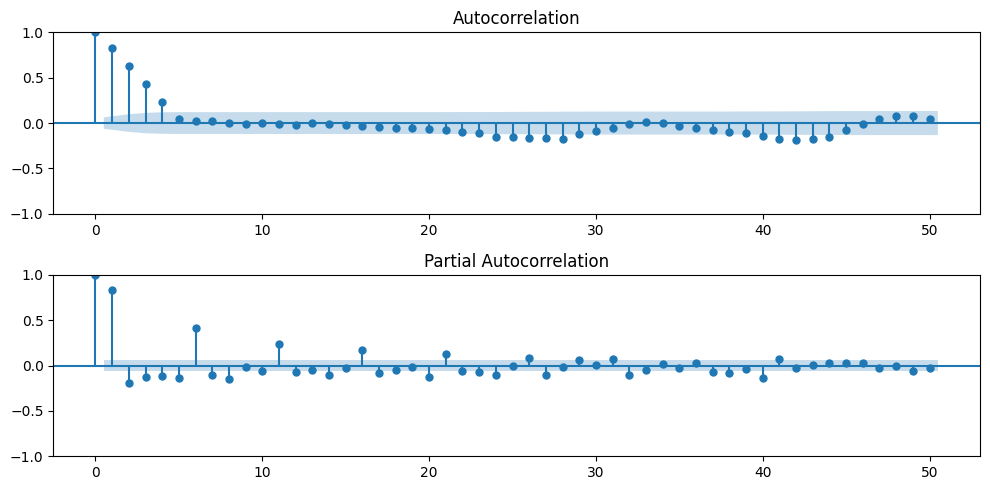

In [211]:
# Проанализируем

fig, ax = plt.subplots(2, 1, figsize=(10, 5))
plot_acf(stocks_returns_1w_daily['GAZP']['log_return'], lags=50, ax=ax[0]);
plot_pacf(stocks_returns_1w_daily['GAZP']['log_return'], lags=50, ax=ax[1]);
plt.tight_layout()
plt.show()

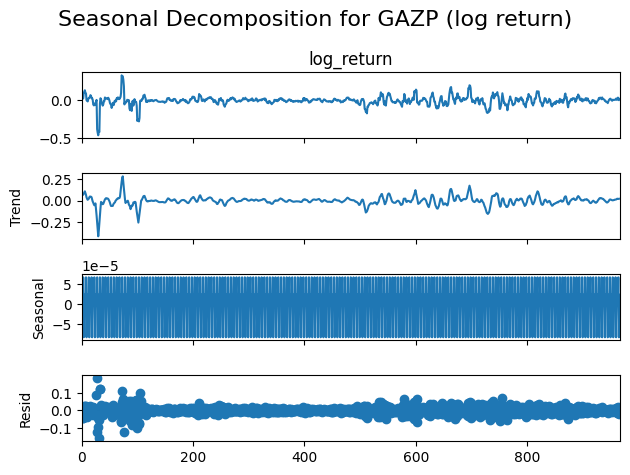

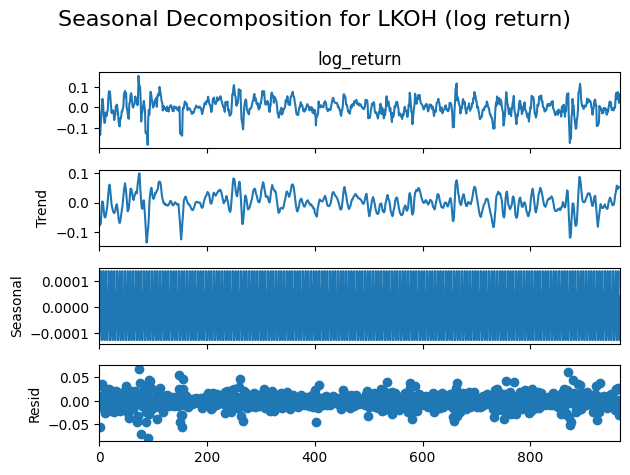

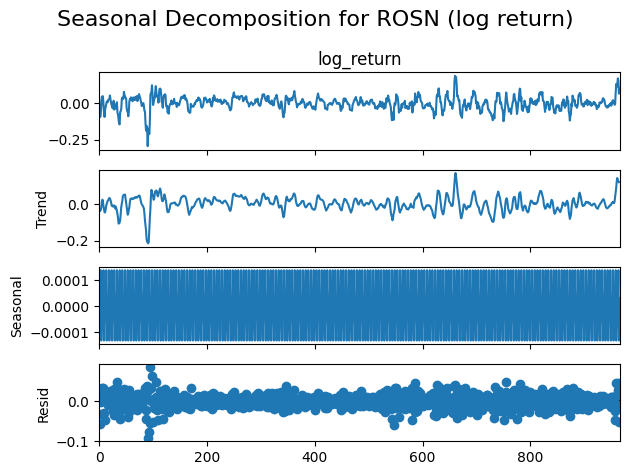

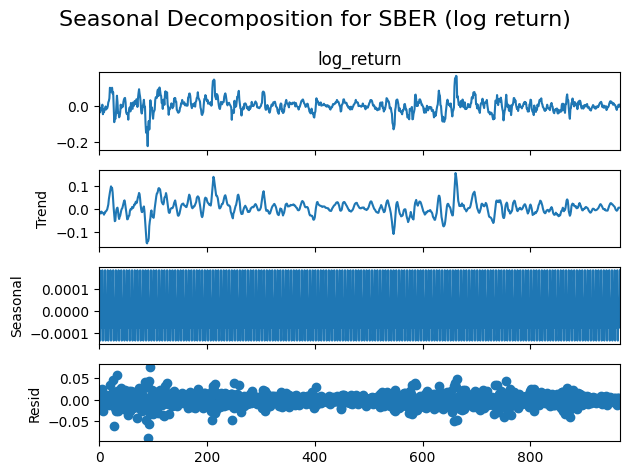

In [212]:
for ticker, df in stocks_returns_1w_daily.items():
    res = seasonal_decompose(df['log_return'], period=5, model='additive')
    fig = res.plot()
    fig.suptitle(f"Seasonal Decomposition for {ticker} (log return)", fontsize=16)
    plt.tight_layout()
    plt.show()

Здесь мы уже видим кое что интересное.

ACF быстро затухает, за 6 дней.

А на PACF наблюдаем всплески, которые происходят примерно каждые 7 дней.

Стоит попробовать модель `AR(2)`.

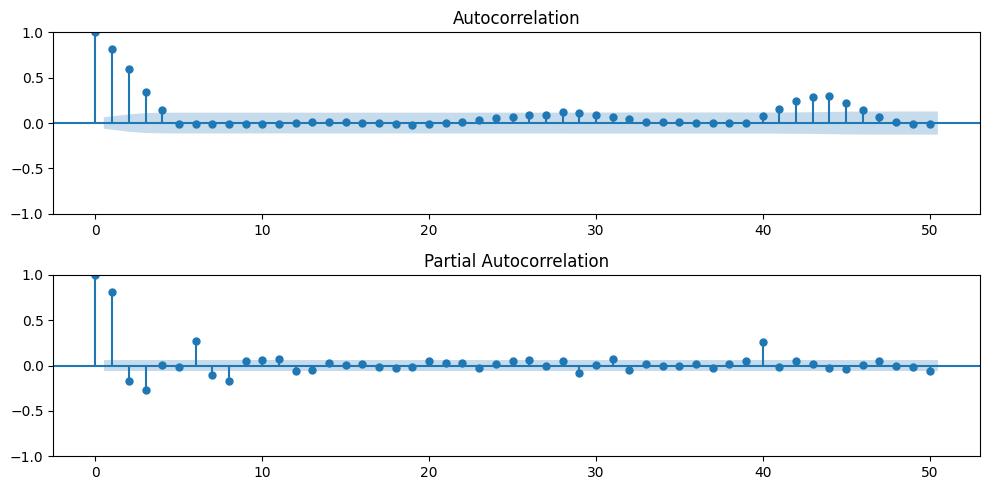

In [213]:
# Попробуем квадраты

fig, ax = plt.subplots(2, 1, figsize=(10, 5))
plot_acf(stocks_returns_1w_daily['GAZP']['log_return'] ** 2, lags=50, ax=ax[0]);
plot_pacf(stocks_returns_1w_daily['GAZP']['log_return'] ** 2, lags=50, ax=ax[1]);
plt.tight_layout()
plt.show()

### 1.4. Пробуем SARIMA модель

In [160]:
# Xtrain_stocks, Xtest_stocks, ytrain_stocks, ytest_stocks = {}, {}, {}, {}

# for ticker, df in stocks_returns_1w_daily.items():
#     Xtrain_stocks[ticker], Xtest_stocks[ticker], ytrain_stocks[ticker], ytest_stocks[ticker] = train_test_split_by_date(
#         df=df, 
#         date_column='begin',
#         target_column='log_return',
#         test_size=0.2
#     )

# Xtrain_stocks['GAZP'].head()

In [161]:
X, y = stocks_returns_1w_daily['GAZP']['close'], stocks_returns_1w_daily['GAZP']['log_return']

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.statespace.sarimax import SARIMAX

tscv_sarima = TimeSeriesSplit(test_size=10, n_splits=20)
for order in ((1,0,0), (2,0,0), (1,0,1)):
    for i, (train_index, test_index) in enumerate(tscv_sarima.split(X)):
        Xtrain = X.iloc[train_index]
        ytrain = y.iloc[train_index]
        Xtest = X.iloc[test_index]
        ytest = y.iloc[test_index]
        print(f"Split {i+1}:")
        print(f"  Train: {Xtrain.index.min()} - {Xtrain.index.max()} ({len(Xtrain)} samples)")
        print(f"  Test:  {Xtest.index.min()} - {Xtest.index.max()} ({len(Xtest)} samples)")
        model = SARIMAX(stocks_returns_1w_daily['GAZP']['log_return'], order=order, seasonal_order=(0, 0, 0, 0), enforce_stationarity=False, enforce_invertibility=False)
        fitted = model.fit(disp=False)
        forecast = fitted.forecast(steps=10)
        
    

790

In [ ]:
# SARIMAX модель
from sklearn.metrics import f1_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

for order in ((1,0,0), (2,0,0), (1,0,1)):
    # Ряд логарифмирован, поэтому он уже стационарный. Сезонности также нет.
    model = SARIMAX(stocks_returns_1w_daily['GAZP']['log_return'], seasonal_order=(0, 0, 0, 0), enforce_stationarity=False, enforce_invertibility=False)
    fitted = model.fit(disp=False)
    print(fitted)
    forecast = fitted.forecast(steps=10)
    print(forecast)


970    0.004676
971    0.004169
972    0.003717
973    0.003314
974    0.002955
975    0.002635
976    0.002349
977    0.002094
978    0.001867
979    0.001665
Name: predicted_mean, dtype: float64
970    0.004676
971    0.004169
972    0.003717
973    0.003314
974    0.002955
975    0.002635
976    0.002349
977    0.002094
978    0.001867
979    0.001665
Name: predicted_mean, dtype: float64
970    0.004676
971    0.004169
972    0.003717
973    0.003314
974    0.002955
975    0.002635
976    0.002349
977    0.002094
978    0.001867
979    0.001665
Name: predicted_mean, dtype: float64
